# Dragon Fruit Classification
Fine-tune the model to classify dragon fruit as either **good** or **bad**.

### Dataset
[https://data.mendeley.com/datasets/cfchfdpfw5/1](https://data.mendeley.com/datasets/cfchfdpfw5/1)

### Classes
* Bad Fruit
* Good Fruit

In [1]:
!pip install -q ultralytics scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Descomprime el archivo en una carpeta llamada 'dataset' dentro del entorno temporal de Colab
!unzip "/content/drive/MyDrive/DragonLeafAndFruit.zip" -d "/content/datasets/"

Archive:  /content/drive/MyDrive/DragonLeafAndFruit.zip
   creating: /content/datasets/DragonLeafAndFruit/
   creating: /content/datasets/DragonLeafAndFruit/Bad fruit/
  inflating: /content/datasets/DragonLeafAndFruit/Bad fruit/BGR (1712)_aug_1.jpg  
  inflating: /content/datasets/DragonLeafAndFruit/Bad fruit/BGR (1712)_aug_2.jpg  
  inflating: /content/datasets/DragonLeafAndFruit/Bad fruit/BGR (1712)_aug_3.jpg  
  inflating: /content/datasets/DragonLeafAndFruit/Bad fruit/BGR (1975)_aug_1.jpg  
  inflating: /content/datasets/DragonLeafAndFruit/Bad fruit/BGR (1975)_aug_2.jpg  
  inflating: /content/datasets/DragonLeafAndFruit/Bad fruit/BGR (1975)_aug_3.jpg  
  inflating: /content/datasets/DragonLeafAndFruit/Bad fruit/BGR (1976)_aug_1.jpg  
  inflating: /content/datasets/DragonLeafAndFruit/Bad fruit/BGR (1976)_aug_2.jpg  
  inflating: /content/datasets/DragonLeafAndFruit/Bad fruit/BGR (1976)_aug_3.jpg  
  inflating: /content/datasets/DragonLeafAndFruit/Bad fruit/BGR (380)_aug_1.jpg  
  i

In [4]:
import torch
from ultralytics import YOLO

print(f"GPU device in use: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "GPU not available, using CPU.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
GPU device in use: Tesla T4


In [5]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

SOURCE_DIR = Path("datasets/DragonLeafAndFruit")
OUTPUT_DIR = Path("datasets/dragon_fruit")

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

CLASSES_TO_USE = ["Good fruit", "Bad fruit", "Without fruit"]
SPLITS = ["train", "val", "test"]

# Create output directory structures
for split in SPLITS:
    for cls in CLASSES_TO_USE:
        (OUTPUT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

# Lambda function to copy image lists to their destination paths
copy_images = lambda img_list, split, cls: [
    shutil.copy(img, OUTPUT_DIR / split / cls / Path(img).name) for img in img_list
]

for cls in CLASSES_TO_USE:
    src_folder = SOURCE_DIR / cls

    # Collect images using native pathlib globbing
    extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]
    images = [img for ext in extensions for img in src_folder.glob(ext)]

    # Target Split Ratio: 70% Train, 15% Validation, 15% Test
    # Step 1: Separate 15% of the total dataset for the final Test set
    train_val_imgs, test_imgs = train_test_split(images, test_size=0.15, random_state=42)

    # Step 2: From the remaining 85%, extract ~17.65% for Validation (0.15 / 0.85 ≈ 0.1765)
    train_imgs, val_imgs = train_test_split(train_val_imgs, test_size=0.1765, random_state=42)

    # Execute file transfers using the copy lambda function
    copy_images(train_imgs, "train", cls)
    copy_images(val_imgs, "val", cls)
    copy_images(test_imgs, "test", cls)

BREAKDOWN BY SPLIT AND CLASS:
 Split          test  train  val
Class                          
Bad fruit       139    643  139
Good fruit      150    699  150
Without fruit   111    516  111

OVERALL CLASS BALANCE:
                Count  Percentage
Class                           
Bad fruit        921   34.650113
Good fruit       999   37.584650
Without fruit    738   27.765237


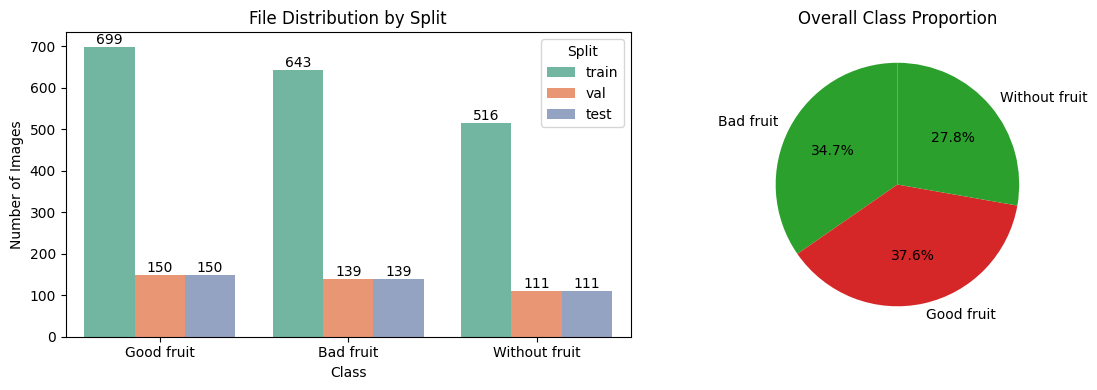

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build DataFrame directly with nested list comprehension
df = pd.DataFrame([
    {
        "Split": s,
        "Class": c,
        "Count": len([f for f in (OUTPUT_DIR / s / c).glob("*") if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    }
    for s in SPLITS for c in CLASSES_TO_USE
])

# Summary tables
print("BREAKDOWN BY SPLIT AND CLASS:\n", df.pivot(index="Class", columns="Split", values="Count"))
total_cls = df.groupby("Class")["Count"].sum().to_frame()
total_cls["Percentage"] = (total_cls["Count"] / total_cls["Count"].sum()) * 100
print("\nOVERALL CLASS BALANCE:\n", total_cls)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot with container labels
bar_ax = sns.barplot(data=df, x="Class", y="Count", hue="Split", ax=axes[0], palette="Set2")
for container in bar_ax.containers: bar_ax.bar_label(container)

# Pie chart
axes[1].pie(total_cls["Count"], labels=total_cls.index, autopct="%1.1f%%", startangle=90, colors=["#2ca02c", "#d62728"])
axes[0].set(title="File Distribution by Split", ylabel="Number of Images")
axes[1].set(title="Overall Class Proportion")

plt.tight_layout()
plt.show()

In [7]:
from ultralytics import YOLO

PROJECT_DIR = "yolo26"
PROJECT_NAME = "dragon_fruit"

model = YOLO("yolo26n-cls.pt")
results = model.train(
    data="datasets/dragon_fruit",
    epochs=25,
    imgsz=320, # (240, 320)
    batch=32,
    project=PROJECT_DIR,
    name=PROJECT_NAME,
    optimizer="AdamW",
    lr0=0.001,
    seed=42,
)

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/dragon_fruit, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=dragon_fruit, nbs=64, nms=None, opset=None, optimi

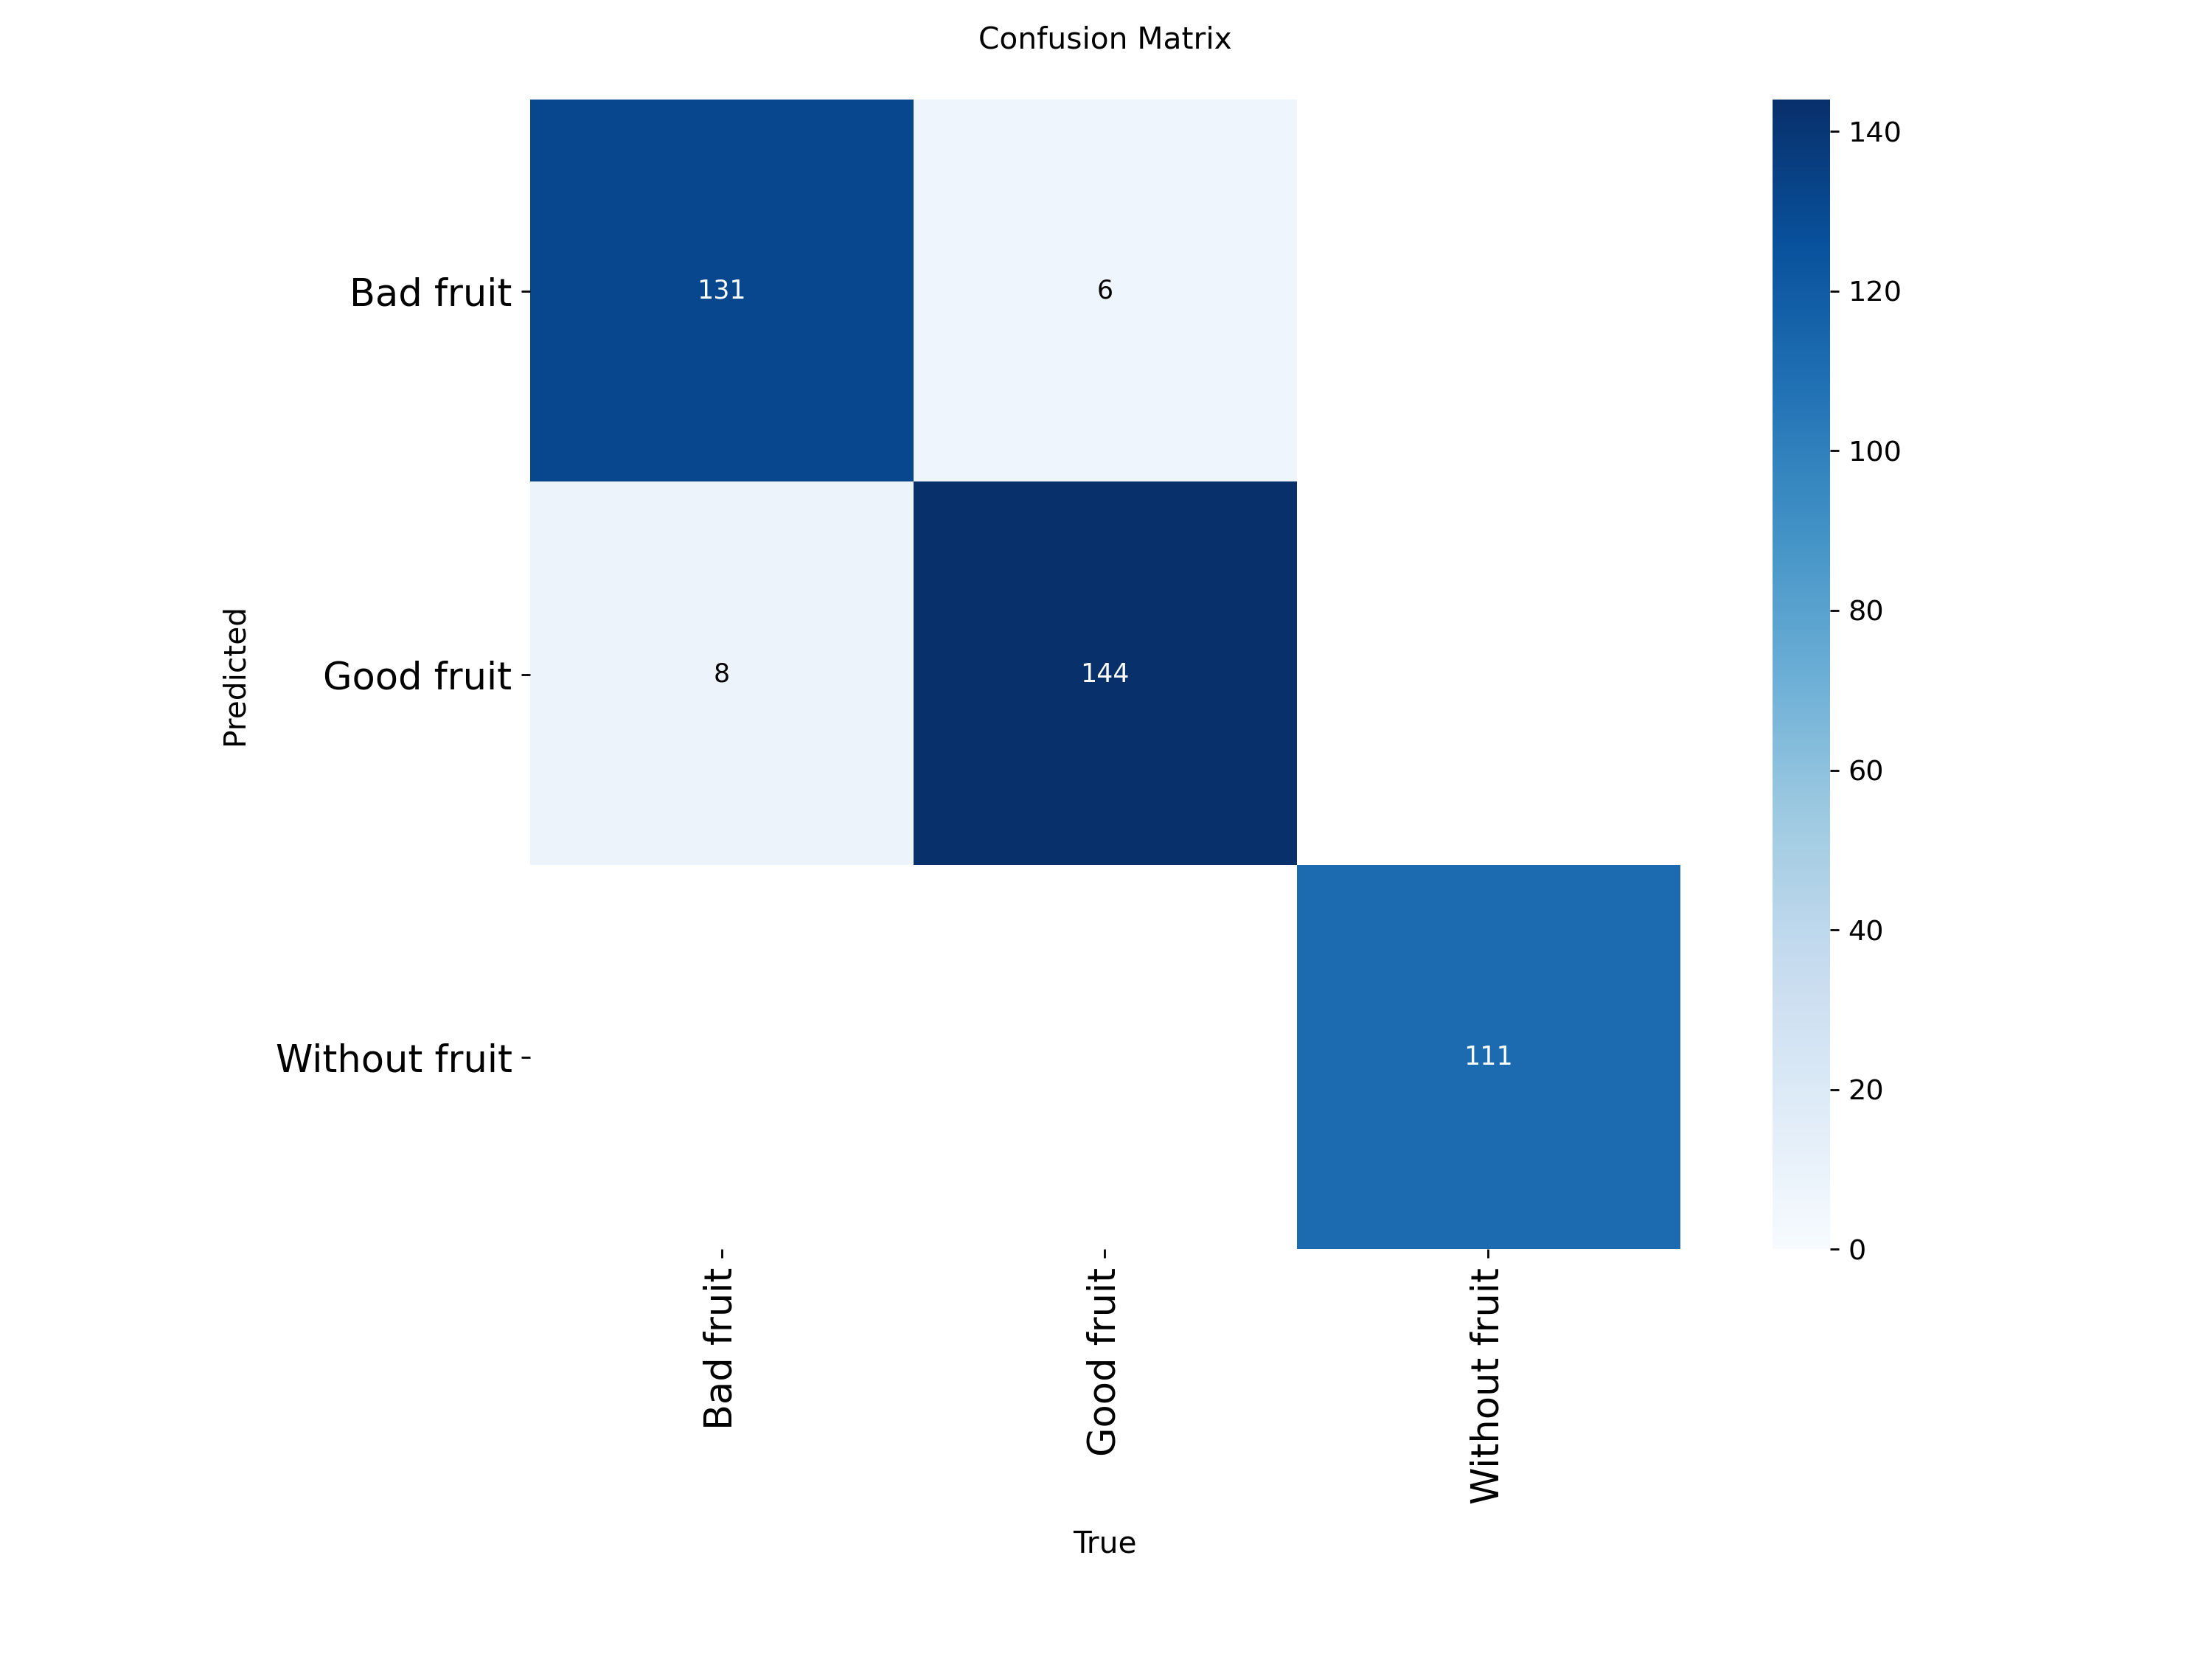

In [9]:
from IPython.display import Image, display

DIR_DRIVE = "drive/MyDrive/dragon_fruit_x3"
DIR_YOLO = f"/content/runs/classify/{PROJECT_DIR}/{PROJECT_NAME}"

shutil.copytree(Path(DIR_YOLO), Path(DIR_DRIVE), dirs_exist_ok=True)
display(Image(filename=f'{DIR_YOLO}/confusion_matrix.png', width=800))

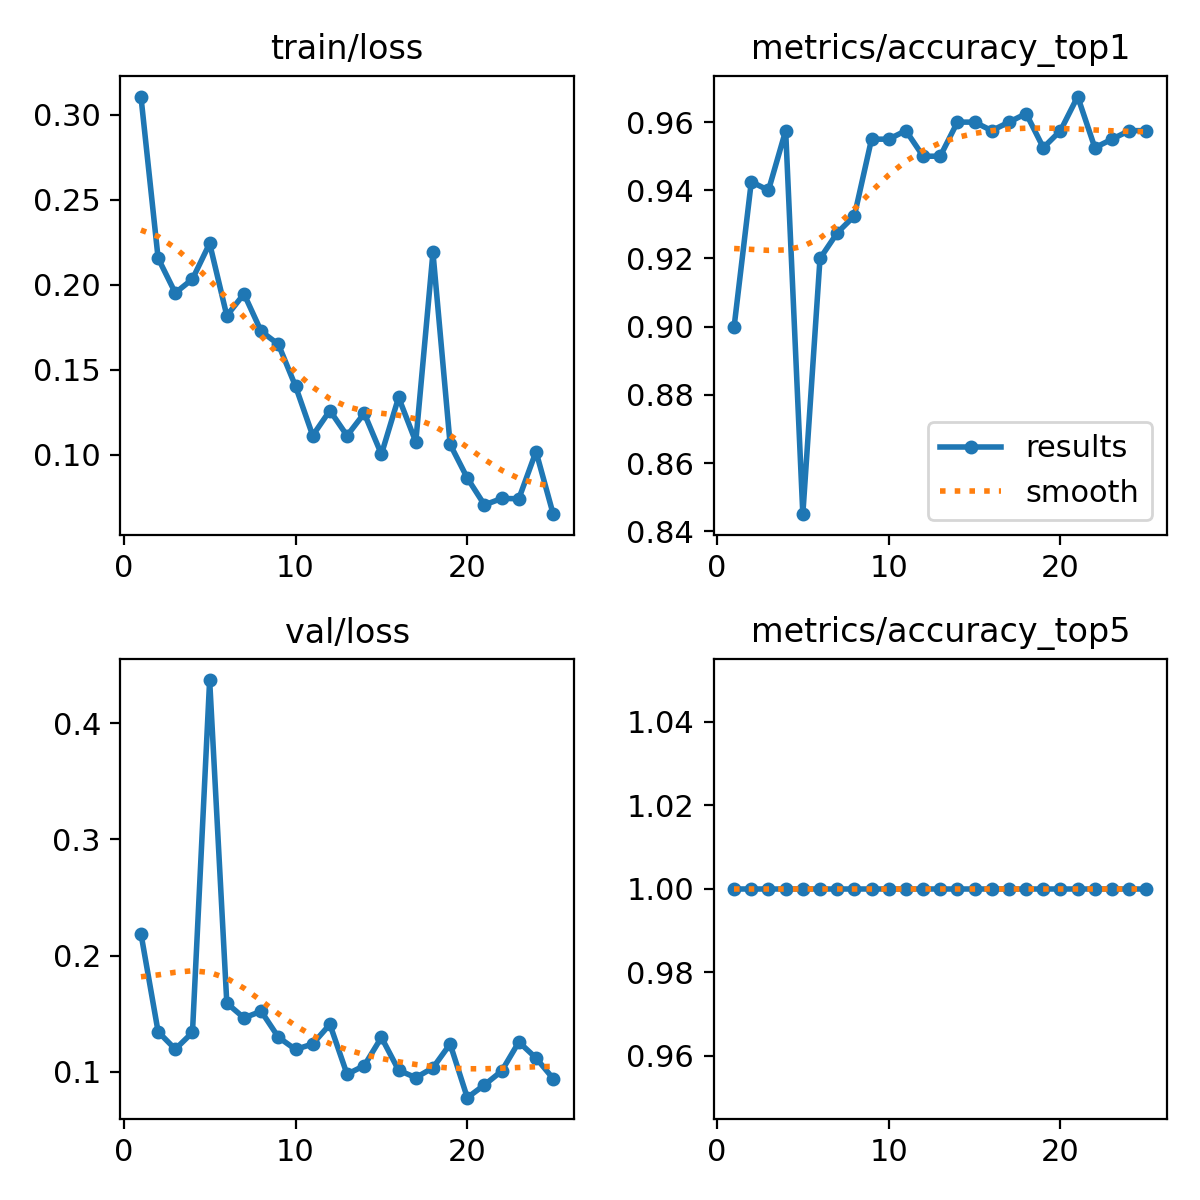

Final Training and Validation Epoch Metrics:


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
24,25,7546.82,0.06493,0.9575,1,0.09416,0.00005,0.00005,0.00005


Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-cls summary (fused): 47 layers, 1,529,867 parameters, 0 gradients, 3.2 GFLOPs
train: /content/datasets/dragon_fruit/train... found 1858 images in 3 classes ✅ 
val: /content/datasets/dragon_fruit/val... found 400 images in 3 classes ✅ 
test: /content/datasets/dragon_fruit/test... found 400 images in 3 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 101.7±150.5 MB/s, size: 173.3 KB)
test: Scanning /content/datasets/dragon_fruit/test... 400 images, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 836.0it/s 0.5s
test: New cache created: /content/datasets/dragon_fruit/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 25/25 2.4s/it 1:00
                   all      0.955          1
Speed: 0.4ms preprocess, 1.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/yolo26/test_evaluation
Test Top-1 Accuracy: 0.9550
=== ACCURACY BY CLASS (T

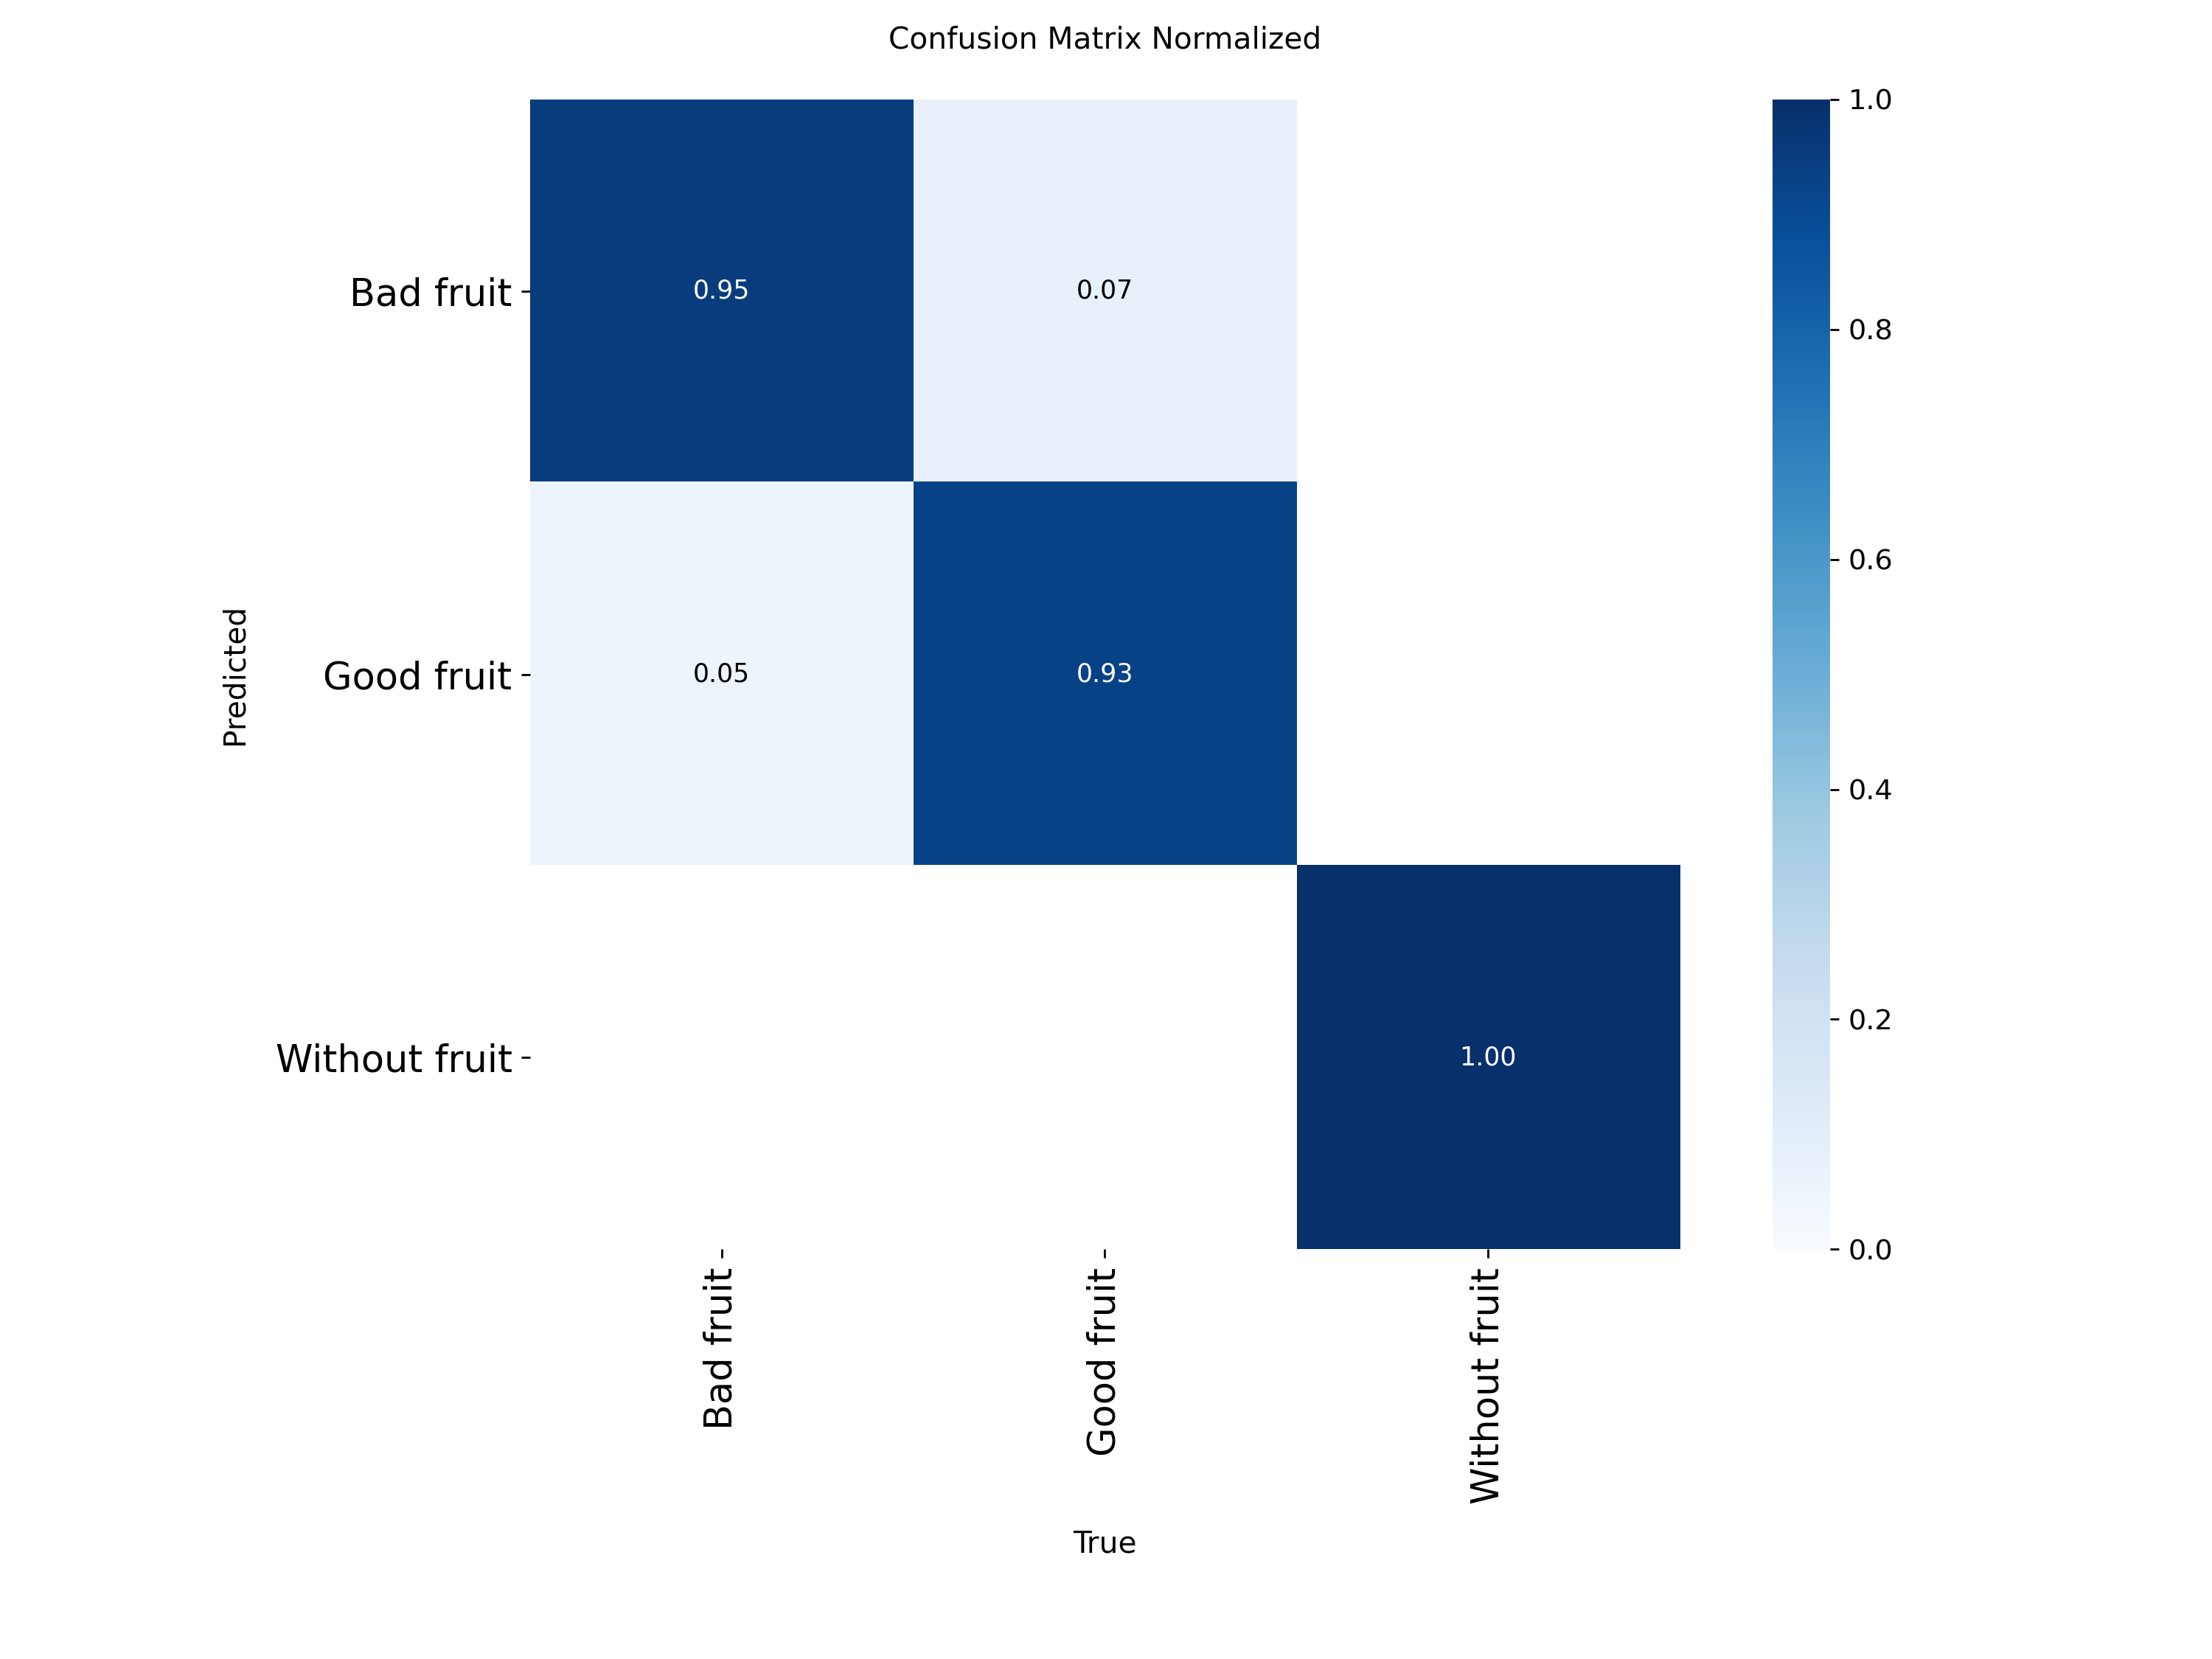

In [11]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display
from ultralytics import YOLO

# ========================== #
# Display Training Metrics   #
# ========================== #
results_plot = Path(DIR_YOLO) / "results.png"

if results_plot.exists():
    display(Image(filename=str(results_plot), width=800))

csv_path = Path(DIR_YOLO) / "results.csv"
if csv_path.exists():
    df_results = pd.read_csv(csv_path)
    df_results.columns = df_results.columns.str.strip()

    print("Final Training and Validation Epoch Metrics:")
    display(df_results.tail(1))

# ==================================== #
# Evaluate Performance on Test Dataset #
# ==================================== #
best_model = YOLO(Path(DIR_YOLO) / "weights" / "best.pt")
test_results = best_model.val(
    data="datasets/dragon_fruit",
    split="test",
    project=PROJECT_DIR,
    name="test_evaluation"
)

print(f"Test Top-1 Accuracy: {test_results.top1:.4f}")

# ==================================== #
# Calculate Accuracy by Class          #
# ==================================== #
confusion_matrix = test_results.confusion_matrix.matrix
class_names = best_model.names  # Dictionary of classes {0: 'bad', 1: 'good'}

print("=== ACCURACY BY CLASS (TEST DATASET) ===")

for class_index, class_name in class_names.items():
    total_actual = confusion_matrix[class_index, :].sum()
    correct_predictions = confusion_matrix[class_index, class_index]

    if total_actual > 0:
        class_accuracy = (correct_predictions / total_actual) * 100
        print(
            f"Class '{class_name}': "
            f"{class_accuracy:.2f}% "
            f"({int(correct_predictions)}/{int(total_actual)} images)"
        )

# ==================================== #
# Display Test Confusion Matrix        #
# ==================================== #
test_confusion_matrix_image = (
    f"runs/classify/{PROJECT_DIR}/test_evaluation/confusion_matrix_normalized.png"
)

display(
    Image(
        filename=str(test_confusion_matrix_image),
        width=800
    )
)